# Optimización Bayesiana

|                |   |
:----------------|---|
| **Nombre**     | David Alejandro Rangel Rodríguez |
| **Fecha**      | 16/03/2026 |
| **Expediente** | 756203  |

**Teorema de Bayes**

$$ P(A|B) = \frac{P(B|A) P(A)}{P(B)} $$

$ P(A|B) $: Probabilidad condicional de A dado B. También conocida como la probabilidad posterior de A dado que B ocurre.

$ P(B|A) $: Probabilidad condicional de B dado A. Se interpreta como la verosimilitud (*likelihood*) de A.

$ P(A) $: Probabilidad de observar A. También conocida como probabilidad a priori.

$ P(B) $: Probabilidad de observar B. Interpretada como evidencia.

Utilizando las definiciones de arriba actualizamos la definición del teorema de bayes:

$$ \text{posterior} = \frac{(\text{verosimilitud})(\text{anterior})}{\text{evidencia}} $$

La intuición es que el teorema de Bayes es una herramienta para actualizar nuestras creencias dado lo que se tenía antes y nueva evidencia. Por ejemplo, tomas una moneda y asumes que es una moneda justa, dado que es lo más probable y que las monedas suelen ser justas en tu experiencia. Lanzas la moneda tres veces y cae sello las tres veces; un poco extraño, así que ajustas tus creencias y empiezas a imaginar que la moneda no es tan justa como debería ser. Lanzas las monedas tres veces y cae águila; ahora crees que la moneda es justa de nuevo.

## ¿Cómo aplicamos esto en nuestra vida diaria?

Imagina que tienes 3 puntos (conocimiento previo) en un espacio.

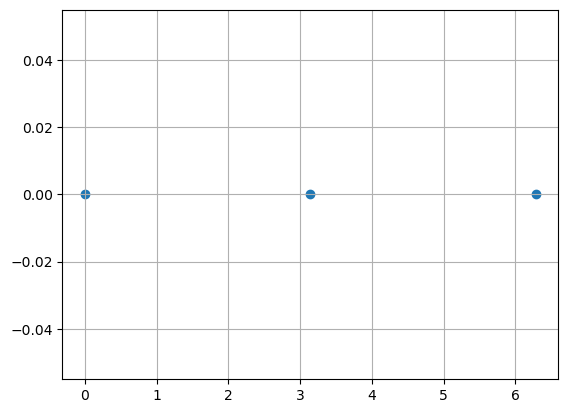

In [7]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(); plt.scatter([0, np.pi, 2*np.pi], [0, 0, 0]); plt.grid()

No hay seguridad de cómo se conectan estos puntos, pero sabes que están conectados. Hay infinitas formas en las que estos puntos se pueden conectar.

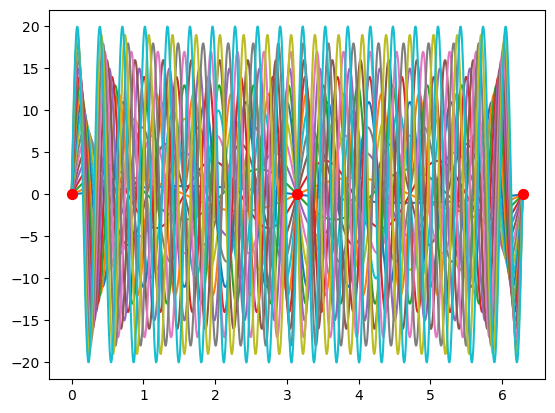

In [17]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); 
for i in range(20) :
    y = (i+1)*np.sin((i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi], [0, 0, 0], s=50, c="r", zorder=3)

Hay tanta incertidumbre que decides pedir más información y te dan otro punto.

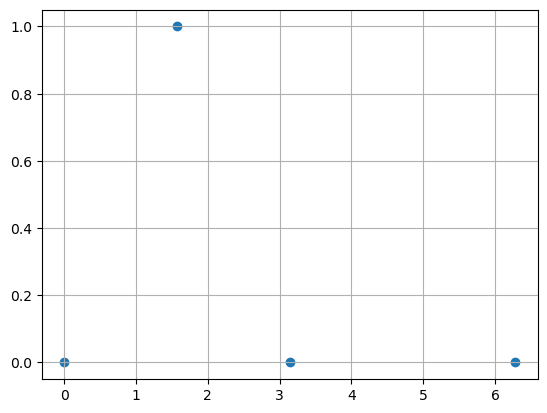

In [18]:
plt.figure(); plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1]); plt.grid()

Con esta nueva información actualizas tus creencias y reduces la cantidad de formas en las que se conectan estos puntos (siguen siendo infinitas).

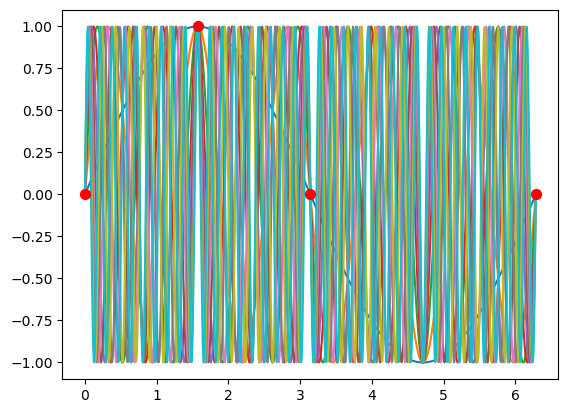

In [29]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); 
for i in range(10) :
    y = np.sin((4*i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1], s=50, c="r", zorder=3)

Te pones a pensar: "Sí. Teóricamente hay infinitas funciones que pueden conectar estos puntos, pero sólo algunas tienen sentido dado mi contexto."

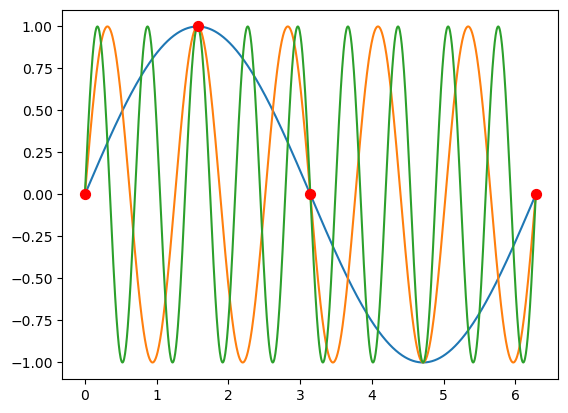

In [30]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); 
for i in range(3) :
    y = np.sin((4*i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1], s=50, c="r", zorder=3)

Ahora sólo quedan algunos pocos candidatos dado el criterio que tienes. Hay incertidumbre sobre cuál de estos candidatos podría ser el que mejor se ajusta, así que decides pedir más información. ¿Qué información serviría más?
- Se podría pedir el valor de $y$ cuando $x=\frac{3\pi}{2}$, pero los candidatos que tenemos todos pasan por el mismo punto. Incluso si nos dieran la información, no ayudaría de mucho.
- Se podría pedir fuera del rango que tenemos, pero quizás la información no existe o dado el contexto del problema es imposible que estos puntos existan.

Nos asignan nuestro último punto.

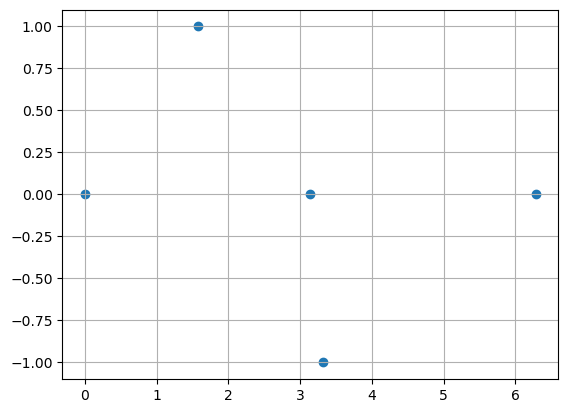

In [59]:
plt.figure(); plt.scatter([0, np.pi, 2*np.pi, np.pi/2, 19*np.pi/18], [0, 0, 0, 1, -1]); plt.grid()

Usamos esta nueva información (evidencia) junto con lo que conocíamos (anterior) y lo que creemos que es posible (verosimilitud) para decidir sobre una nueva función (posterior).

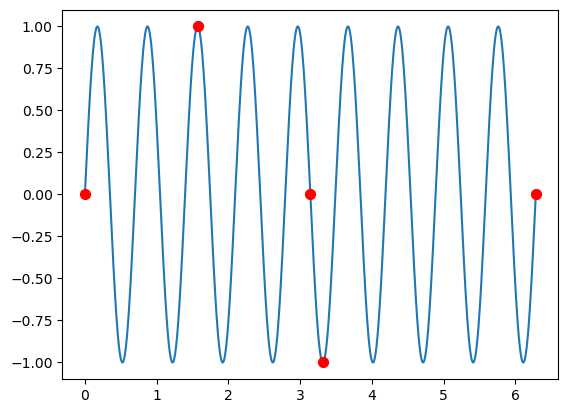

In [172]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); y = np.sin(9*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2, 19*np.pi/18], [0, 0, 0, 1, -1], s=50, c="r", zorder=3)

Una forma de realizar este experimento es mediante un proceso gaussiano, que asume que la variable de salida es una variable aleatoria con distribución normal multivariada. Utilicemos la función que encontramos y asumamos que no sabemos cuál es.

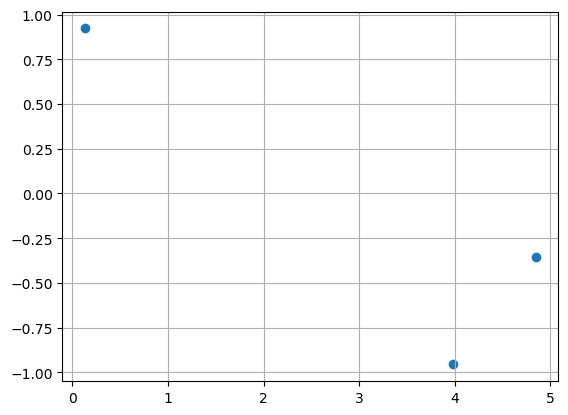

In [183]:
np.random.seed(10)
def f(x) :
    return np.sin(9*x)
X = np.random.uniform(0, 2*np.pi, 3).reshape([-1, 1])
plt.figure(); plt.scatter(X, f(X)); plt.grid()

Realizamos una regresión de proceso gaussiano para encontrar distribuciones que podrían darnos estas muestras

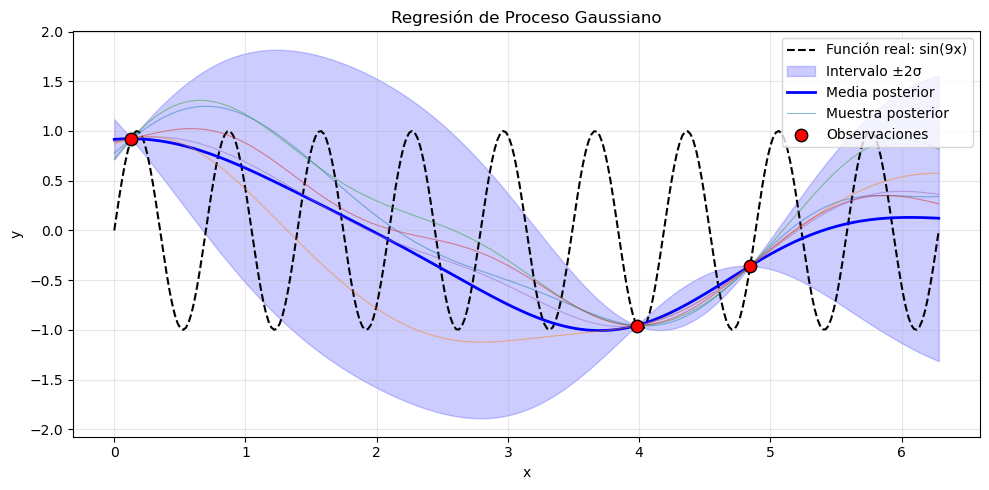

Kernel optimizado: 0.81**2 * RBF(length_scale=1.03)
Log-verosimilitud marginal: -3.280


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Datos originales
np.random.seed(10)

def f(x):
    return np.sin(9 * x)

X = np.random.uniform(0, 2 * np.pi, 3).reshape([-1, 1])
y = f(X).ravel()

# Kernel: amplitud * RBF  (Define qué tan similares son dos puntos)
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

# Modelo GPR (Muestra una distribución de probabilidad sobre funciones enteras).
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6)
gp.fit(X, y)

# Predicción sobre una malla densa 
X_pred = np.linspace(0, 2 * np.pi, 300).reshape([-1, 1])
y_mean, y_std = gp.predict(X_pred, return_std=True)

# Muestras de la distribución posterior
y_samples = gp.sample_y(X_pred, n_samples=5, random_state=42)

# Gráfica 
plt.figure(figsize=(10, 5))

# Función verdadera
plt.plot(X_pred, f(X_pred), 'k--', label='Función real: sin(9x)', linewidth=1.5)

# Banda de incertidumbre (±2σ)
plt.fill_between(
    X_pred.ravel(),
    y_mean - 2 * y_std,
    y_mean + 2 * y_std,
    alpha=0.2, color='blue', label='Intervalo ±2σ'
)

# Media posterior
plt.plot(X_pred, y_mean, 'b-', label='Media posterior', linewidth=2)

# Muestras de la posterior
for i, sample in enumerate(y_samples.T):
    plt.plot(X_pred, sample, alpha=0.5, linewidth=0.8,
             label='Muestra posterior' if i == 0 else '')

# Puntos de entrenamiento
plt.scatter(X, y, c='red', zorder=5, s=80, label='Observaciones', edgecolors='k')

plt.title('Regresión de Proceso Gaussiano')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Kernel optimizado: {gp.kernel_}")
print(f"Log-verosimilitud marginal: {gp.log_marginal_likelihood_value_:.3f}")

Creamos un vector de valores posibles de $x$ y predecimos $y$ usando el resultado de la regresión.

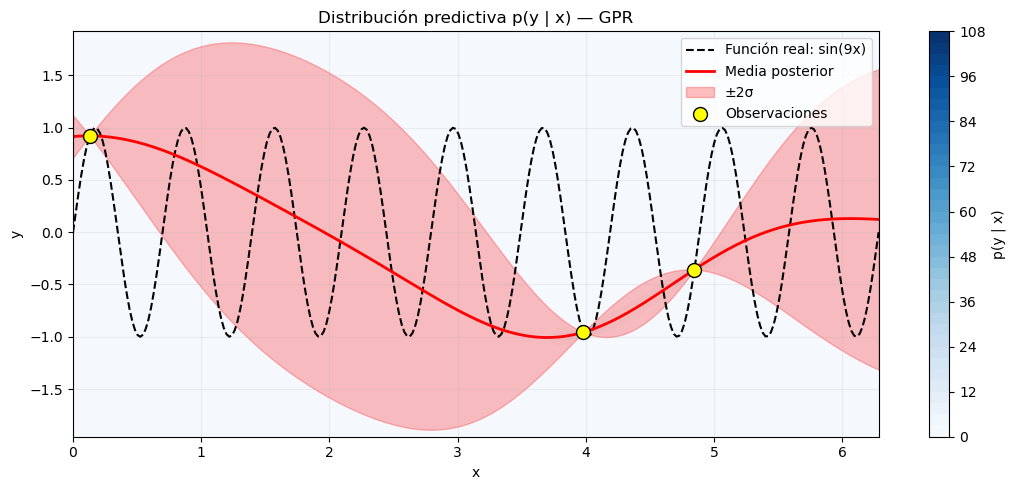

In [4]:
# Vector de valores posibles de y 
y_values = np.linspace(f(X).min() - 1, f(X).max() + 1, 300)

# Para cada punto de prueba, obtenemos la distribución p(y* | x*)
X_pred = np.linspace(0, 2 * np.pi, 300).reshape([-1, 1])
y_mean, y_std = gp.predict(X_pred, return_std=True)

# Evaluamos la densidad gaussiana en cada punto
from scipy.stats import norm

# Matriz de densidades: shape (n_x_pred, n_y_values)
densidades = np.array([
    norm.pdf(y_values, loc=mu, scale=sigma)
    for mu, sigma in zip(y_mean, y_std)
])

# Gráfica
plt.figure(figsize=(11, 5))

# Heatmap de densidades p(y | x)
plt.contourf(X_pred.ravel(), y_values, densidades.T, levels=40, cmap='Blues')
plt.colorbar(label='p(y | x)')

# Función real
plt.plot(X_pred, f(X_pred), 'k--', label='Función real: sin(9x)', linewidth=1.5)

# Media posterior
plt.plot(X_pred, y_mean, 'r-', label='Media posterior', linewidth=2)

# Banda ±2σ
plt.fill_between(
    X_pred.ravel(),
    y_mean - 2 * y_std,
    y_mean + 2 * y_std,
    alpha=0.25, color='red', label='±2σ'
)

# Observaciones
plt.scatter(X, y, c='yellow', zorder=5, s=100, edgecolors='k', label='Observaciones')

plt.title('Distribución predictiva p(y | x) — GPR')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Graficamos nuestra primera propuesta, utilizando el error estándar para dibujar nuestros intervalos de confianza.

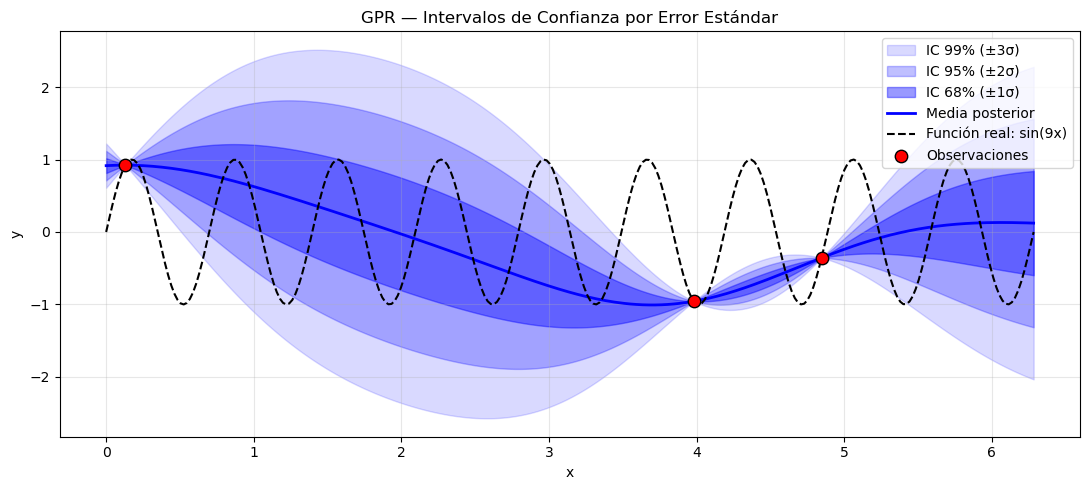

       x |    Media |       SE |  IC 95% inferior |  IC 95% superior
-----------------------------------------------------------------
   0.000 |    0.915 |    0.102 |            0.712 |            1.119
   1.240 |    0.479 |    0.669 |           -0.859 |            1.817
   2.501 |   -0.387 |    0.726 |           -1.840 |            1.065
   3.762 |   -1.005 |    0.112 |           -1.229 |           -0.780
   5.022 |   -0.223 |    0.088 |           -0.398 |           -0.048
   6.283 |    0.122 |    0.719 |           -1.315 |            1.560


In [6]:
# Predicción 
X_pred = np.linspace(0, 2 * np.pi, 300).reshape([-1, 1])
y_mean, y_std = gp.predict(X_pred, return_std=True)

# Error estándar (std de la predictiva)
se = y_std  # en GPR, y_std ya es el error estándar puntual

# Intervalos de confianza
ic_68 = 1 * se   # ±1σ ~ 68%
ic_95 = 2 * se   # ±2σ ~ 95%
ic_99 = 3 * se   # ±3σ ~ 99%

# --- Gráfica ---
plt.figure(figsize=(11, 5))

# Intervalos de confianza (de mayor a menor para que se superpongan bien)
plt.fill_between(X_pred.ravel(), y_mean - ic_99, y_mean + ic_99,
                 alpha=0.15, color='blue', label='IC 99% (±3σ)')
plt.fill_between(X_pred.ravel(), y_mean - ic_95, y_mean + ic_95,
                 alpha=0.25, color='blue', label='IC 95% (±2σ)')
plt.fill_between(X_pred.ravel(), y_mean - ic_68, y_mean + ic_68,
                 alpha=0.40, color='blue', label='IC 68% (±1σ)')

# Media posterior
plt.plot(X_pred, y_mean, 'b-', linewidth=2, label='Media posterior')

# Función real
plt.plot(X_pred, f(X_pred), 'k--', linewidth=1.5, label='Función real: sin(9x)')

# Observaciones
plt.scatter(X, y, c='red', zorder=5, s=80, edgecolors='k', label='Observaciones')

plt.title('GPR — Intervalos de Confianza por Error Estándar')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Resumen numérico
print(f"{'x':>8} | {'Media':>8} | {'SE':>8} | {'IC 95% inferior':>16} | {'IC 95% superior':>16}")
print("-" * 65)
indices = np.linspace(0, len(X_pred)-1, 6, dtype=int)
for i in indices:
    x_val  = X_pred[i, 0]
    mu     = y_mean[i]
    sigma  = se[i]
    print(f"{x_val:>8.3f} | {mu:>8.3f} | {sigma:>8.3f} | {mu - 2*sigma:>16.3f} | {mu + 2*sigma:>16.3f}")

Podemos ver que necesitamos más muestras debido a que hay mucha incertidumbre en algunas partes de nuestro dominio. Hay varios criterios para decidir cómo pedir muestras:
- Maximizar (busco mi predicción del máximo actual y pido esa medida)
- Minimizar (busco mi predicción del mínimo actual y pido esa medida)
- Reducir incertidumbre (busco el punto donde mi intervalo de confianza es más grande y pido esa medida)

Y repetimos el proceso ya con nueva información.

Repitamos el proceso 30 veces con una función distinta.

$$ f(x) = \sin{(\frac{x}{3})} + \cos{(2x)},\ \ \ \ x \in [-5\pi, 5\pi] $$

C:\Users\range\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\range\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\range\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\range\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: Converg

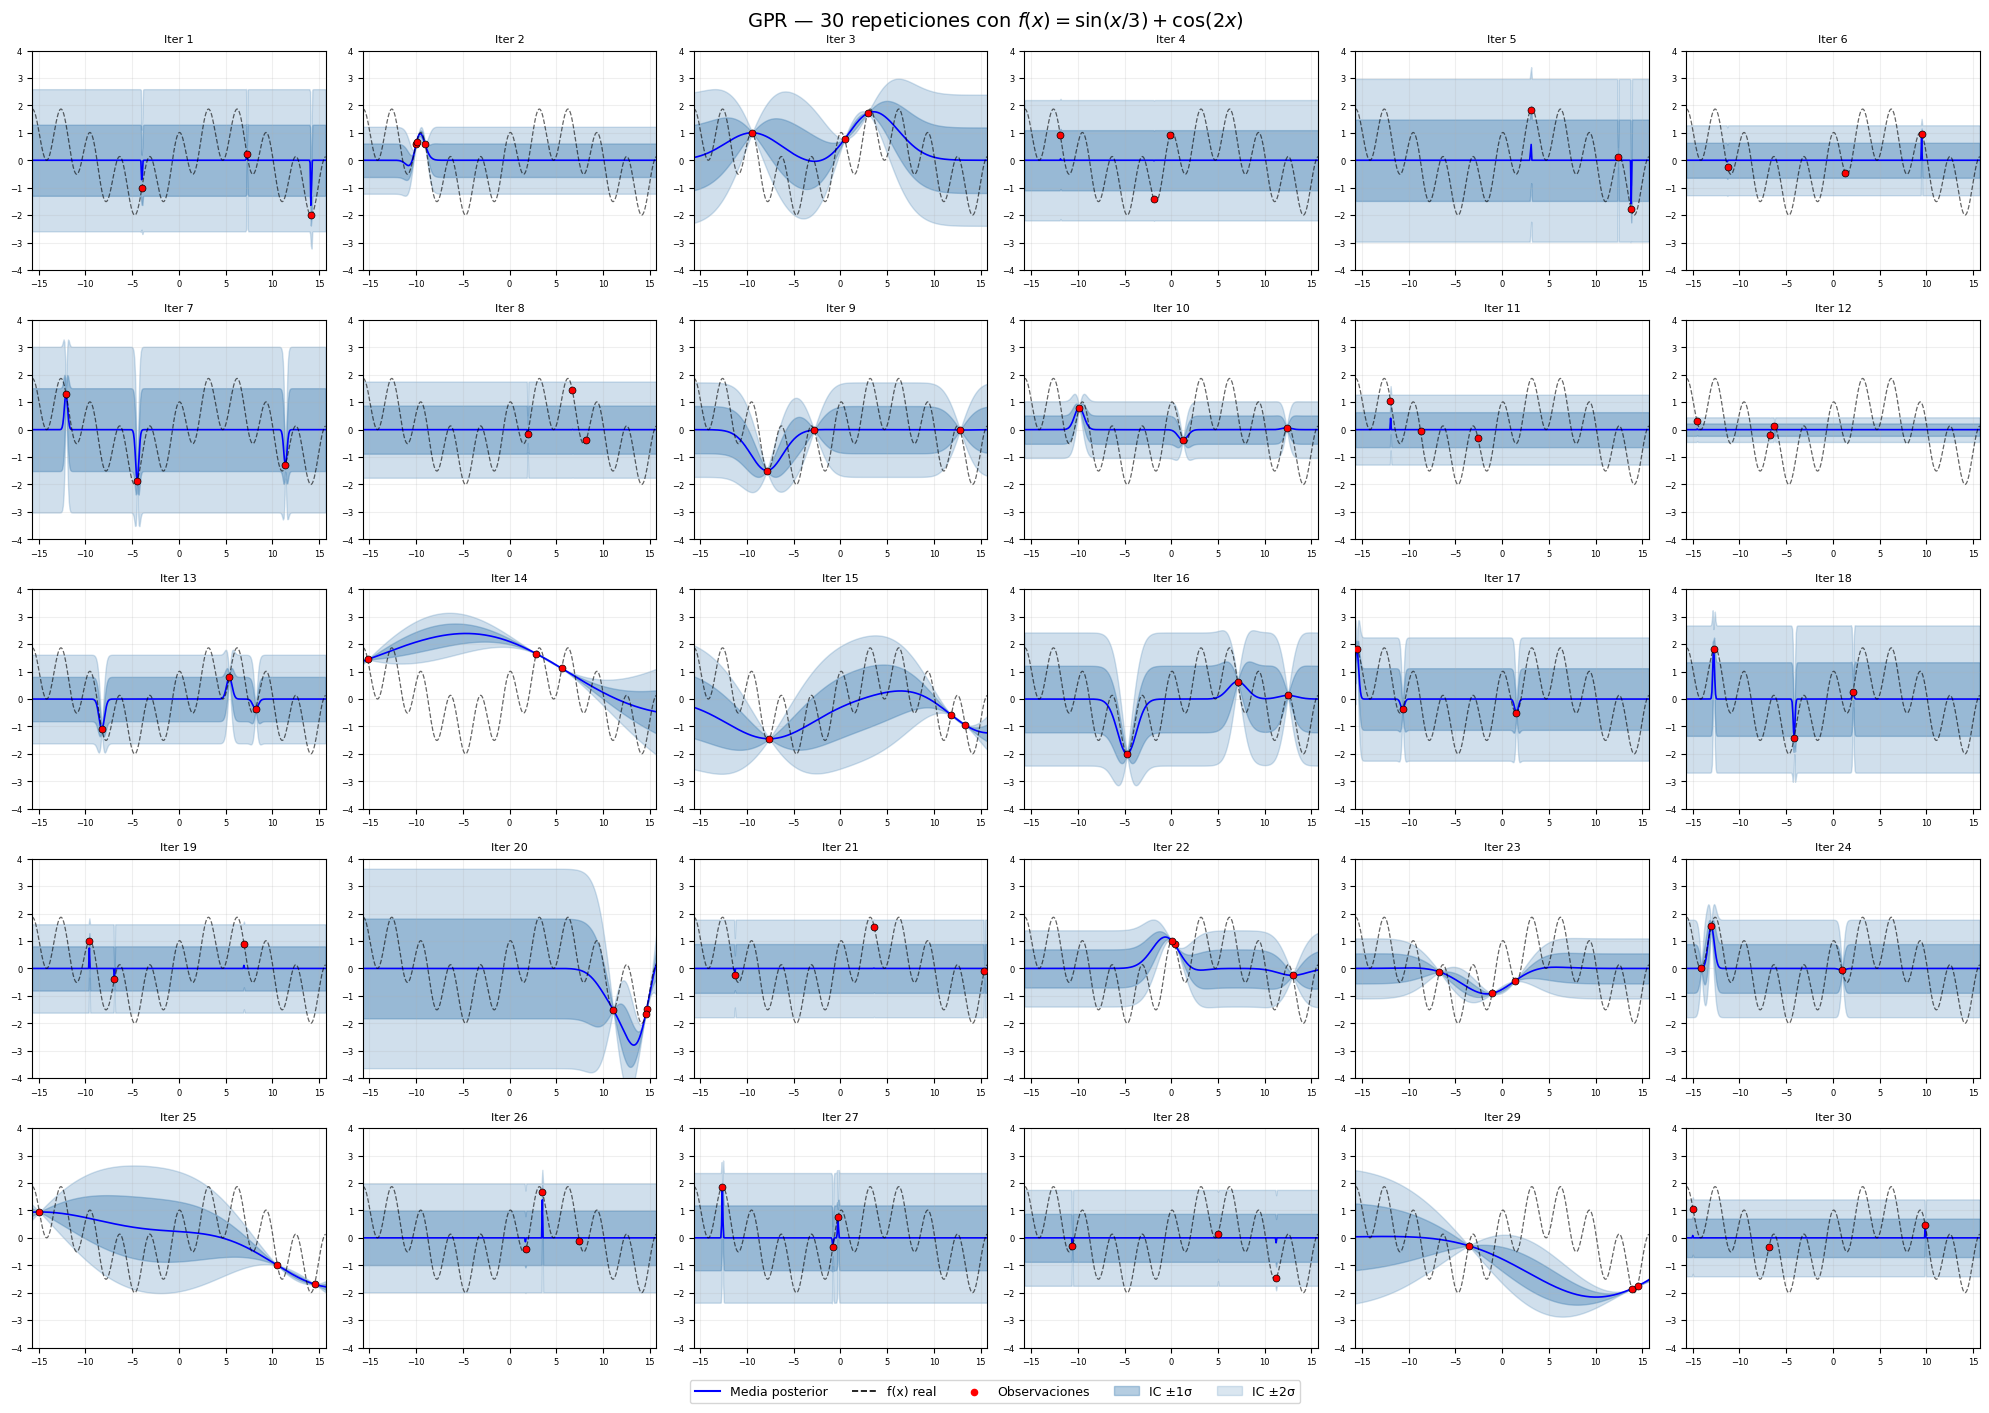

In [7]:
np.random.seed(42)

def f2(x):
    return np.sin(x / 3) + np.cos(2 * x)

X_pred = np.linspace(-5 * np.pi, 5 * np.pi, 400).reshape([-1, 1])

# Kernel 
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

fig, axes = plt.subplots(5, 6, figsize=(20, 14))
axes = axes.ravel()

for i in range(30):
    # Muestra 3 puntos aleatorios en cada iteración
    X_i = np.random.uniform(-5 * np.pi, 5 * np.pi, 3).reshape([-1, 1])
    y_i = f2(X_i).ravel()

    # Ajuste GPR
    gp_i = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, alpha=1e-6)
    gp_i.fit(X_i, y_i)

    # Predicción
    y_mean, y_std = gp_i.predict(X_pred, return_std=True)

    ax = axes[i]

    # Intervalos de confianza
    ax.fill_between(X_pred.ravel(), y_mean - 2*y_std, y_mean + 2*y_std,
                    alpha=0.25, color='steelblue')
    ax.fill_between(X_pred.ravel(), y_mean - y_std, y_mean + y_std,
                    alpha=0.40, color='steelblue')

    # Media posterior y función real
    ax.plot(X_pred, y_mean, 'b-', linewidth=1.2)
    ax.plot(X_pred, f2(X_pred), 'k--', linewidth=0.9, alpha=0.6)

    # Observaciones
    ax.scatter(X_i, y_i, c='red', zorder=5, s=25, edgecolors='k', linewidths=0.5)

    ax.set_title(f'Iter {i+1}', fontsize=8)
    ax.set_xlim(-5*np.pi, 5*np.pi)
    ax.set_ylim(-4, 4)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=6)

# Leyenda global
fig.legend(
    handles=[
        plt.Line2D([0], [0], color='b', linewidth=1.5, label='Media posterior'),
        plt.Line2D([0], [0], color='k', linewidth=1.2, linestyle='--', label='f(x) real'),
        plt.scatter([], [], c='red', s=20, label='Observaciones'),
        plt.fill_between([], [], [], color='steelblue', alpha=0.4, label='IC ±1σ'),
        plt.fill_between([], [], [], color='steelblue', alpha=0.2, label='IC ±2σ'),
    ],
    loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(r'GPR — 30 repeticiones con $f(x) = \sin(x/3) + \cos(2x)$', fontsize=14)
plt.tight_layout()
plt.show()

### Actividad

1. Modificar el comportamiento de selección para elegir el máximo de las predicciones como el siguiente punto.
2. Modificar el comportamiento de selección para elegir el mínimo de las predicciones como el siguiente punto.

C:\Users\range\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


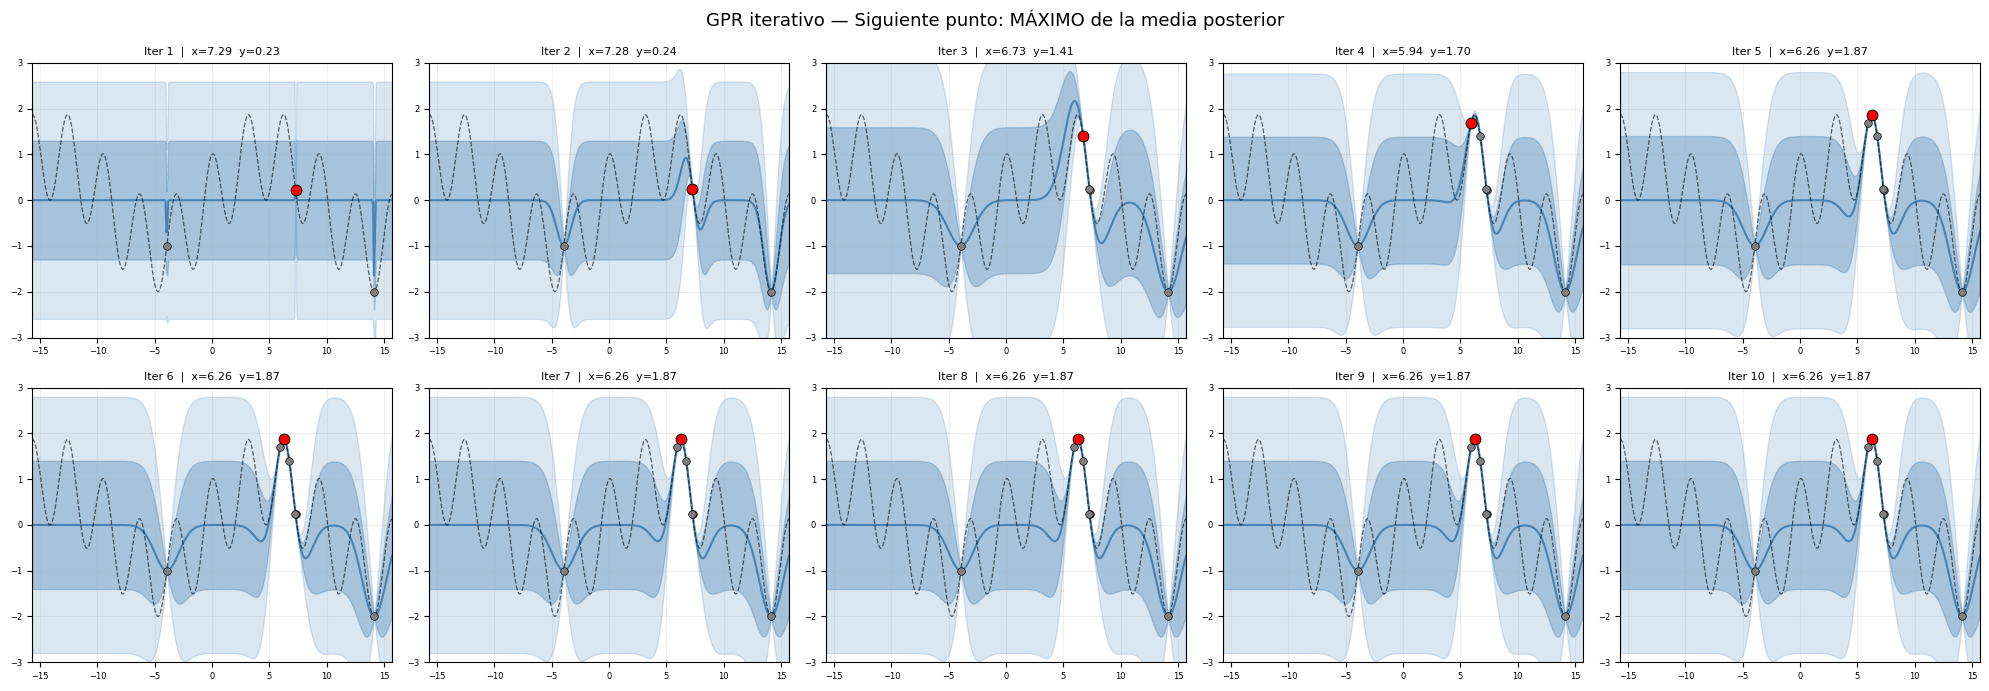

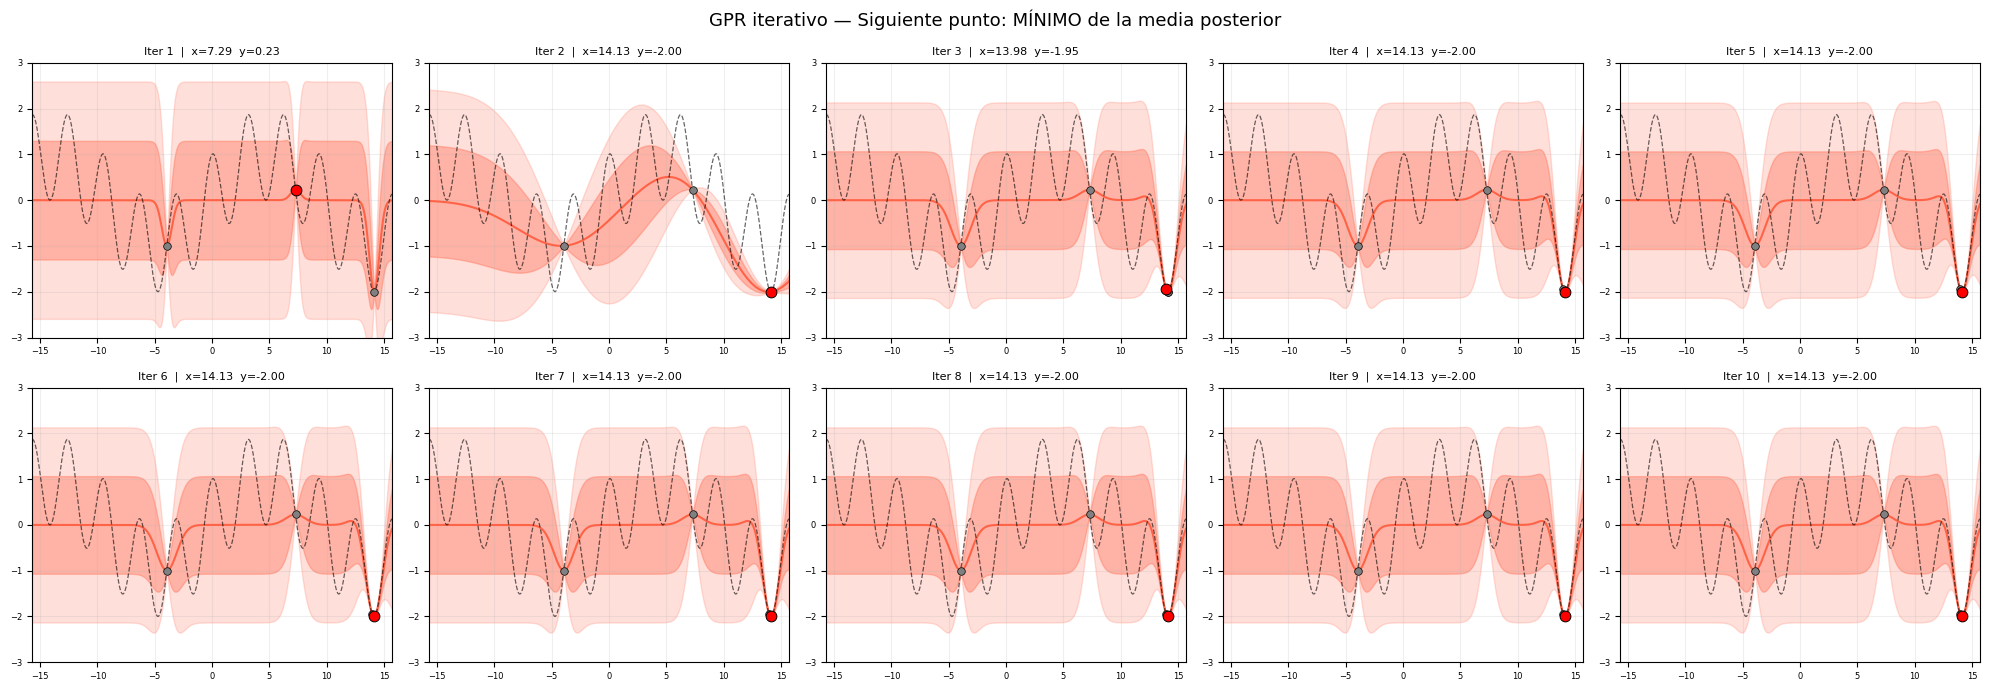

In [9]:
# UTILIDAD COMÚN
def gpr_iterativo(f, x_init, n_iter, selector, titulo, color):
    """
    Ejecuta GPR iterativo agregando un punto nuevo por iteración.
    selector : función que recibe (y_mean, X_pred) y devuelve el índice del siguiente punto
    """
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
    X_pred = np.linspace(-5 * np.pi, 5 * np.pi, 400).reshape([-1, 1])

    X_obs = x_init.copy()
    y_obs = f(X_obs).ravel()

    fig, axes = plt.subplots(2, 5, figsize=(20, 7))
    axes = axes.ravel()

    for i in range(n_iter):
        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, alpha=1e-6)
        gp.fit(X_obs, y_obs)
        y_mean, y_std = gp.predict(X_pred, return_std=True)

        ax = axes[i]
        ax.fill_between(X_pred.ravel(), y_mean - 2*y_std, y_mean + 2*y_std,
                        alpha=0.20, color=color)
        ax.fill_between(X_pred.ravel(), y_mean - y_std, y_mean + y_std,
                        alpha=0.35, color=color)
        ax.plot(X_pred, y_mean, color=color, linewidth=1.5, label='Media posterior')
        ax.plot(X_pred, f(X_pred), 'k--', linewidth=0.9, alpha=0.6, label='f(x) real')
        ax.scatter(X_obs[:-1], y_obs[:-1], c='gray',  zorder=5, s=30, edgecolors='k', linewidths=0.5)
        ax.scatter(X_obs[-1],  y_obs[-1],  c='red',   zorder=6, s=60, edgecolors='k', linewidths=0.7,
                   label='Nuevo punto')

        ax.set_title(f'Iter {i+1}  |  x={X_obs[-1,0]:.2f}  y={y_obs[-1]:.2f}', fontsize=8)
        ax.set_xlim(-5*np.pi, 5*np.pi)
        ax.set_ylim(-3, 3)
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=6)

        # --- Selección del siguiente punto ---
        idx_next = selector(y_mean, X_pred)
        x_next   = X_pred[idx_next].reshape([1, 1])
        y_next   = f(x_next).ravel()
        X_obs    = np.vstack([X_obs, x_next])
        y_obs    = np.append(y_obs, y_next)

    fig.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

np.random.seed(42)
def f2(x):
    return np.sin(x / 3) + np.cos(2 * x)

X_init = np.random.uniform(-5*np.pi, 5*np.pi, 3).reshape([-1, 1])

# 1. SELECCIÓN POR MÁXIMO
def selector_max(y_mean, X_pred):
    return np.argmax(y_mean)

gpr_iterativo(
    f        = f2,
    x_init   = X_init.copy(),
    n_iter   = 10,
    selector = selector_max,
    titulo   = r'GPR iterativo — Siguiente punto: MÁXIMO de la media posterior',
    color    = 'steelblue'
)

# 2. SELECCIÓN POR MÍNIMO
def selector_min(y_mean, X_pred):
    return np.argmin(y_mean)

gpr_iterativo(
    f        = f2,
    x_init   = X_init.copy(),
    n_iter   = 10,
    selector = selector_min,
    titulo   = r'GPR iterativo — Siguiente punto: MÍNIMO de la media posterior',
    color    = 'tomato'
)